In [59]:
import numpy as np 
import pandas as pd
from pathlib import Path
import pycountry
import json 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nicolsleyva/traveltommasterdataset/traveltom_clean.csv
/kaggle/input/datasets/nicolsleyva/traveltommasterdataset/stats_clean.json
/kaggle/input/datasets/nicolsleyva/traveltommasterdataset/cities_metadata.csv


In [60]:
DATASET_PATH = '/kaggle/input/datasets/nicolsleyva/traveltommasterdataset/traveltom_clean.csv'
OUTPUT_PATH = Path("/kaggle/working/traveltom_clean2.csv")

In [61]:
df = pd.read_csv(DATASET_PATH, low_memory=False)

In [62]:
print(df.columns)

Index(['business_id', 'name', 'city', 'state', 'country', 'country_name',
       'continent', 'latitude', 'longitude', 'stars', 'review_count',
       'categories', 'attributes', 'hours', 'is_open', 'address',
       'price_level', 'description', 'website', 'phone', 'image_url', 'source',
       'entity_type', 'popularity'],
      dtype='object')


In [63]:
COLS_TO_DROP = [
    "image_url", 
    "hours",      
    "phone",     
    "website",    
    "address",    
]

#High Null %


df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)
print(f"\n Dropped {len(COLS_TO_DROP)} no-signal columns → {df.shape[1]} columns remain")


[Step 2] Dropped 5 no-signal columns → 19 columns remain


In [65]:
if "state" in df.columns:
    df.drop(columns=["state"], inplace=True)
    print("Dropped 'state' (61% null, geographically inconsistent)")

[Step 3] Dropped 'state' (61% null, geographically inconsistent)


In [66]:
if "is_open" in df.columns:
    dominant_pct = df["is_open"].value_counts(normalize=True).iloc[0] * 100
    if dominant_pct > 90:
        df.drop(columns=["is_open"], inplace=True)
        print(f"Dropped 'is_open' (dominant class at {dominant_pct:.1f}% — near-zero variance)")
    else:
        print(f"Kept 'is_open' (dominant class at {dominant_pct:.1f}% — sufficient variance)")

[Step 3] Dropped 'is_open' (dominant class at 100.0% — near-zero variance)


In [67]:
OVERRIDES = {
    "KR": "South Korea",
    "TW": "Taiwan",
    "IR": "Iran",
    "SY": "Syria",
    "VE": "Venezuela",
    "BO": "Bolivia",
    "MD": "Moldova",
    "TZ": "Tanzania",
}
 
def iso2_to_country_name(code):
    if pd.isna(code) or not isinstance(code, str):
        return None
    code = code.strip().upper()
    if code in OVERRIDES:
        return OVERRIDES[code]
    c = pycountry.countries.get(alpha_2=code)
    return c.name if c else None
 
mask = df["country_name"].isna()
df.loc[mask, "country_name"] = df.loc[mask, "country"].apply(iso2_to_country_name)
 
still_missing = df["country_name"].isna().sum()
filled = mask.sum() - still_missing
print(f"\n country_name: filled {filled:,} rows via ISO lookup | {still_missing:,} still null")
if still_missing > 0:
    print(f"         Unresolved codes: {df[df['country_name'].isna()]['country'].value_counts().head(10).to_dict()}")


[Step 4] country_name: filled 26,448 rows via ISO lookup | 0 still null


In [68]:
print(df.columns)

Index(['business_id', 'name', 'city', 'country', 'country_name', 'continent',
       'latitude', 'longitude', 'stars', 'review_count', 'categories',
       'attributes', 'price_level', 'description', 'source', 'entity_type',
       'popularity'],
      dtype='object')


In [69]:
df["_popularity_check"] = df["stars"] * np.log1p(df["review_count"])
corr = df[["popularity", "_popularity_check"]].corr().iloc[0, 1]
max_diff = (df["popularity"] - df["_popularity_check"]).abs().max()
 
print(f"\n popularity validation:")
print(f"         Correlation with recomputed : {corr:.6f}")
print(f"         Max absolute difference     : {max_diff:.6f}")
 
if corr > 0.999:
    print("Stored 'popularity' matches formula — keeping as authoritative")
else:
    print("Mismatch detected — overwriting 'popularity' with recomputed values")
    df["popularity"] = df["_popularity_check"]
 
df.drop(columns=["_popularity_check"], inplace=True)


[Step 5] popularity validation:
         Correlation with recomputed : 1.000000
         Max absolute difference     : 0.000332
         ✅ Stored 'popularity' matches formula — keeping as authoritative


In [70]:
ATTRIBUTE_KEYS = [
    "wheelchair", "fee", "internet_access", "smoking", "air_conditioning",
    "takeaway", "capacity", "delivery", "outdoor_seating",
    "diet_vegetarian", "diet_vegan",
]
 
def parse_attributes(val):
    if pd.isna(val) or val == "":
        return {}
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        return {}
 
attrs_flat = pd.json_normalize(df["attributes"].apply(parse_attributes))
attrs_flat.index = df.index
 
existing_keys = [k for k in ATTRIBUTE_KEYS if k in attrs_flat.columns]
attrs_flat = attrs_flat[existing_keys]
attrs_flat.columns = [f"attr_{col}" for col in attrs_flat.columns]
 
df = pd.concat([df.drop(columns=["attributes"]), attrs_flat], axis=1)
print(f"\n Parsed attributes into {len(existing_keys)} boolean columns: {attrs_flat.columns.tolist()}")
print(f"         Coverage per attribute (%):")
print((attrs_flat.notna().sum() / len(df) * 100).round(1).to_string())
 


[Step 6] Parsed attributes into 11 boolean columns: ['attr_wheelchair', 'attr_fee', 'attr_internet_access', 'attr_smoking', 'attr_air_conditioning', 'attr_takeaway', 'attr_capacity', 'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian', 'attr_diet_vegan']
         Coverage per attribute (%):
attr_wheelchair          1.4
attr_fee                 0.2
attr_internet_access     0.8
attr_smoking             0.4
attr_air_conditioning    0.2
attr_takeaway            0.2
attr_capacity            0.1
attr_delivery            0.1
attr_outdoor_seating     0.5
attr_diet_vegetarian     0.3
attr_diet_vegan          0.1


In [71]:
ENTITY_LABELS = {"restaurant", "hotel", "attraction"}
 
def clean_categories(val):
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(";")]
    cleaned = [p for p in parts if p.lower() not in ENTITY_LABELS]
    return ";".join(cleaned) if cleaned else None
 
df["categories"] = df["categories"].apply(clean_categories)
null_after = df["categories"].isna().sum()
print(f"\n Stripped entity prefix from 'categories'")
print(f"         Null categories after cleaning: {null_after:,}")


[Step 7] Stripped entity prefix from 'categories'
         Null categories after cleaning: 10,910


In [73]:
cols = ["stars", "review_count", "popularity"]

for col in cols:
    print(f"\n===== {col.upper()} BY SOURCE =====")
    print(df.groupby("source")[col].describe())
    print("\nUnique values per source:")
    print(df.groupby("source")[col].nunique())


===== STARS BY SOURCE =====
                  count      mean       std  min  25%  50%  75%  max
source                                                              
michelin         7501.0  4.168964  0.243358  4.0  4.0  4.0  4.2  5.0
openstreetmap   13332.0  3.990849  0.142942  1.0  4.0  4.0  4.0  5.0
tbo_hotels     123037.0  4.000000  0.000000  4.0  4.0  4.0  4.0  4.0
tripadvisor      5615.0  4.000000  0.000000  4.0  4.0  4.0  4.0  4.0

Unique values per source:
source
michelin         5
openstreetmap    6
tbo_hotels       1
tripadvisor      1
Name: stars, dtype: int64

===== REVIEW_COUNT BY SOURCE =====
                  count  mean  std   min   25%   50%   75%   max
source                                                          
michelin         7501.0  50.0  0.0  50.0  50.0  50.0  50.0  50.0
openstreetmap   13332.0   0.0  0.0   0.0   0.0   0.0   0.0   0.0
tbo_hotels     123037.0   0.0  0.0   0.0   0.0   0.0   0.0   0.0
tripadvisor      5615.0   0.0  0.0   0.0   0.0   0.0   0.0  

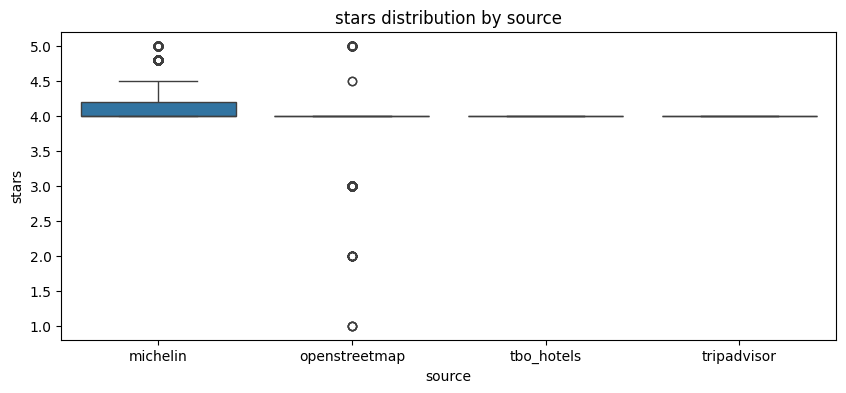

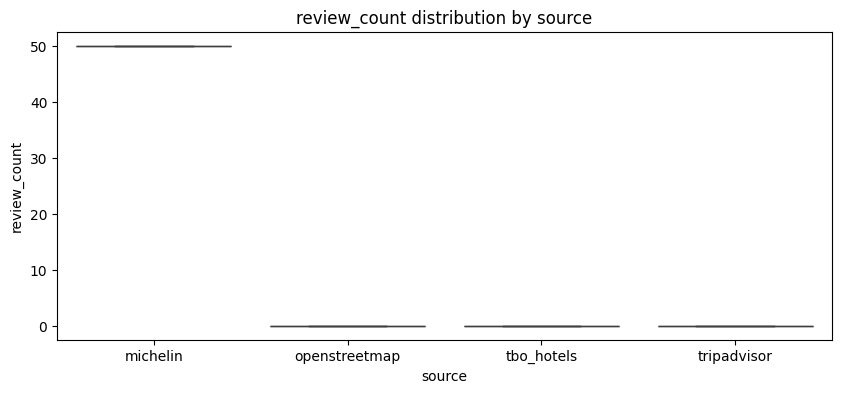

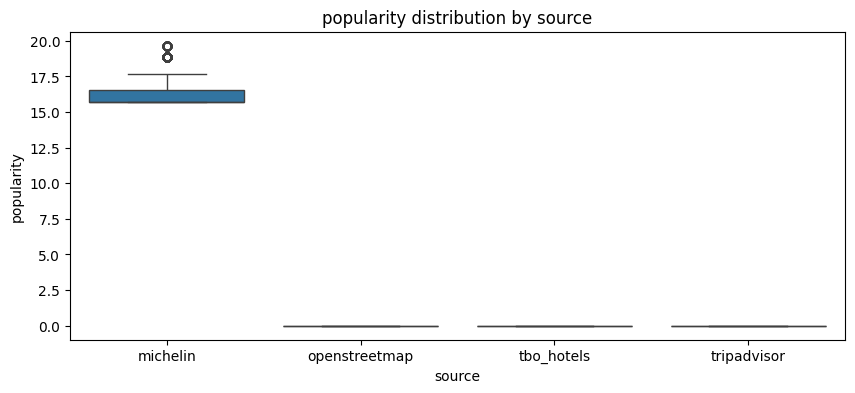

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x="source", y=col)
    plt.title(f"{col} distribution by source")
    plt.show()

In [75]:
print(df["review_count"].value_counts().sort_index())

review_count
0     141984
50      7501
Name: count, dtype: int64


In [76]:
print("Unique values:", df["review_count"].unique())
print("Number of unique:", df["review_count"].nunique())

Unique values: [50  0]
Number of unique: 2


In [77]:
for col in ["stars", "popularity"]:
    print(f"\n{col}")
    print("Mean:", df[col].mean())
    print("Std:", df[col].std())
    print("Unique:", df[col].nunique())


stars
Mean: 4.0076623072549085
Std: 0.07858031237143696
Unique: 8

popularity
Mean: 0.8225081513195306
Std: 3.58492006091586
Unique: 6


In [78]:
def is_usable_target(series):
    return series.nunique() > 20 and series.std() > 0.5

print("stars usable:", is_usable_target(df["stars"]))
print("popularity usable:", is_usable_target(df["popularity"]))
print("review_count usable:", is_usable_target(df["review_count"]))

stars usable: False
popularity usable: False
review_count usable: False


In [79]:
attr_cols = [c for c in df.columns if c.startswith("attr_")]

for col in attr_cols:
    df[col] = df[col].notna().astype(int)

df["has_any_attributes"] = df[attr_cols].sum(axis=1) > 0
df["has_any_attributes"] = df["has_any_attributes"].astype(int)

In [80]:
df["categories_clean"] = df["categories"].fillna("").str.lower()
df["description_clean"] = df["description"].fillna("").str.lower()

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_text = vectorizer.fit_transform(
    df["categories_clean"] + " " + df["description_clean"]
)

In [82]:
df["lat_lon"] = df["latitude"].fillna(0).astype(str) + "_" + df["longitude"].fillna(0).astype(str)

In [83]:
import numpy as np


df["desc_len"] = df["description"].fillna("").apply(len)

df["desc_score"] = (df["desc_len"] - df["desc_len"].min()) / (
    df["desc_len"].max() - df["desc_len"].min()
)

df["cat_count"] = df["categories"].fillna("").apply(lambda x: len(x.split(",")))
df["cat_score"] = df["cat_count"] / df["cat_count"].max()

df["quality_score"] = 0.6 * df["desc_score"] + 0.4 * df["cat_score"]

In [ ]:
#Synthetic Stars Data Populating
df["stars"] = 2.7 + (df["quality_score"] ** 0.5) * (5 - 2.7)

df["stars"] += np.random.normal(0, 0.1, len(df))

df["stars"] = df["stars"].clip(2.7, 5.0)

In [85]:
base = df["quality_score"] * 100

df["review_count"] = np.random.lognormal(mean=3, sigma=1, size=len(df))
df["review_count"] = df["review_count"] * (1 + base)
df["review_count"] = df["review_count"].astype(int)

In [86]:
df["popularity"] = (df["stars"] * np.log1p(df["review_count"]))

In [87]:
print(df[["stars", "review_count", "popularity"]].describe())
print(df["stars"].nunique())
print(df["review_count"].nunique())

               stars   review_count     popularity
count  149485.000000  149485.000000  149485.000000
mean        4.148976    1555.279031      27.471101
std         0.596529    2403.344403       8.871085
min         2.700000       1.000000       2.040196
25%         4.064547     263.000000      23.173367
50%         4.436054     827.000000      29.824069
75%         4.536901    1896.000000      33.768482
max         4.949082   90726.000000      51.218481
149472
10173


In [88]:
print(df.columns)

Index(['business_id', 'name', 'city', 'country', 'country_name', 'continent',
       'latitude', 'longitude', 'stars', 'review_count', 'categories',
       'price_level', 'description', 'source', 'entity_type', 'popularity',
       'attr_wheelchair', 'attr_fee', 'attr_internet_access', 'attr_smoking',
       'attr_air_conditioning', 'attr_takeaway', 'attr_capacity',
       'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian',
       'attr_diet_vegan', 'has_any_attributes', 'categories_clean',
       'description_clean', 'lat_lon', 'desc_len', 'desc_score', 'cat_count',
       'cat_score', 'quality_score'],
      dtype='object')


               stars   review_count     popularity
count  149485.000000  149485.000000  149485.000000
mean        4.148976    1555.279031      27.471101
std         0.596529    2403.344403       8.871085
min         2.700000       1.000000       2.040196
25%         4.064547     263.000000      23.173367
50%         4.436054     827.000000      29.824069
75%         4.536901    1896.000000      33.768482
max         4.949082   90726.000000      51.218481
149472
10173
Shape: (149485, 36)

Data types:
 business_id               object
name                      object
city                      object
country                   object
country_name              object
continent                 object
latitude                 float64
longitude                float64
stars                    float64
review_count               int64
categories                object
price_level              float64
description               object
source                    object
entity_type               object

,latitude,longitude
count,143835.000000,143835.000000
mean,28.002982,25.619548
std,26.103947,69.765362
min,-58.391740,-124.053833
25%,18.918816,-2.736295
50%,38.402629,11.558540
75%,46.178935,100.391330
max,71.041859,175.755850


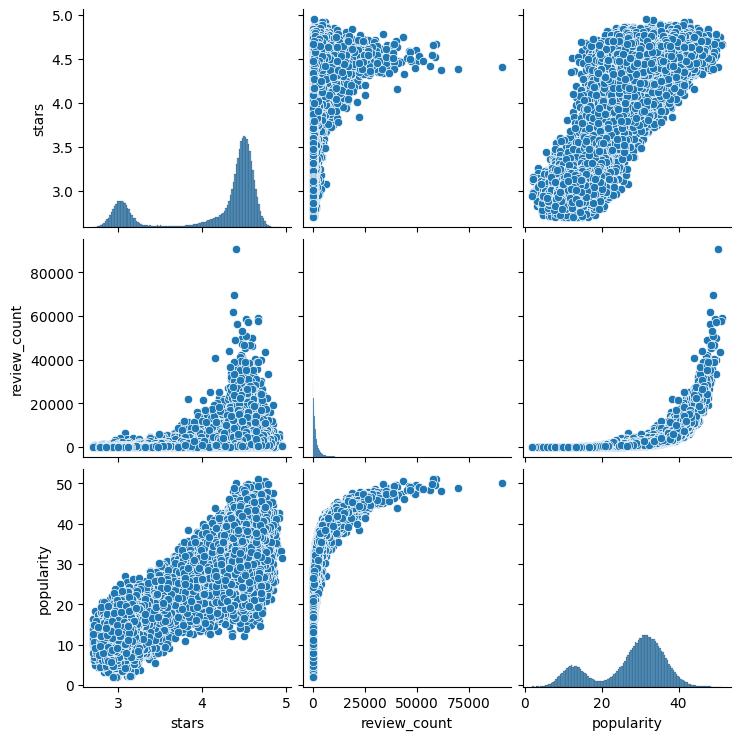

In [89]:
print(df[["stars", "review_count", "popularity"]].describe())
print(df["stars"].nunique())
print(df["review_count"].nunique())
print("==============================")
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False))
print("==============================")
df[["stars", "review_count", "popularity"]].describe()
print("==============================")
for col in ["stars", "review_count", "popularity"]:
    print(col, "unique values:", df[col].nunique())

print("==============================")
sns.pairplot(df[["stars", "review_count", "popularity"]])
print("==============================")
for col in ["stars", "review_count", "popularity"]:
    print(f"\n==== {col} by source ====")
    print(df.groupby("source")[col].agg(["mean", "std", "nunique"]))
print("==============================")
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct)
print("==============================")
print("Empty descriptions:", (df["description"].fillna("") == "").mean())
print("==============================")
df["categories"].str.split(",").explode().value_counts().head(20)
print("==============================")
low_variance_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Low variance columns:", low_variance_cols)
print("==============================")
print("Duplicate rows:", df.duplicated().sum())
df.duplicated(subset=["name", "city"]).sum()
print("==============================")
df[["latitude", "longitude"]].describe()




In [90]:
for col in ["stars", "review_count", "popularity"]:
    print(col, "unique values:", df[col].nunique())

stars unique values: 149472
review_count unique values: 10173
popularity unique values: 149485


In [91]:
for col in ["stars", "review_count", "popularity"]:
    df[f"{col}_norm"] = df.groupby("source")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

In [92]:
print(df[["stars", "stars_norm"]].head())

      stars  stars_norm
0  2.981647   -0.693491
1  2.980539   -0.702929
2  3.109762    0.398198
3  2.942178   -1.029811
4  3.096593    0.285980


In [93]:
df = df.drop(columns=[
    "price_level",        # 95% missing
    "lat_lon",            # redundant
    "business_id"         # uneeded 
])

In [94]:
df = df.drop(columns=["categories"])  

In [95]:
df["description_clean"] = df["description_clean"].fillna("")
df["categories_clean"] = df["categories_clean"].fillna("")

In [96]:
plot_df = df.dropna(subset=['latitude', 'longitude'])

median_lat = df["latitude"].median()
plot_df = df[df["latitude"] != median_lat]

In [97]:
df["missing_description"] = (df["description_clean"] == "").astype(int)
df["missing_location"] = df["latitude"].isna().astype(int)

In [100]:
top_countries = df["country"].value_counts().head(20).index

df["country_grouped"] = df["country"].apply(
    lambda x: x if x in top_countries else "other"
)

df = pd.get_dummies(df, columns=["country_grouped"], drop_first=True)

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

text_features = vectorizer.fit_transform(
    df["categories_clean"] + " " + df["description_clean"]
)

In [102]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "desc_len", "cat_count",
    "quality_score"
]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [106]:
print(df.columns)

Index(['name', 'city', 'country', 'country_name', 'continent', 'latitude',
       'longitude', 'stars', 'review_count', 'description', 'popularity',
       'attr_wheelchair', 'attr_fee', 'attr_internet_access', 'attr_smoking',
       'attr_air_conditioning', 'attr_takeaway', 'attr_capacity',
       'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian',
       'attr_diet_vegan', 'has_any_attributes', 'categories_clean',
       'description_clean', 'desc_len', 'desc_score', 'cat_count', 'cat_score',
       'quality_score', 'stars_norm', 'review_count_norm', 'popularity_norm',
       'missing_description', 'missing_location', 'source_openstreetmap',
       'source_tbo_hotels', 'source_tripadvisor', 'entity_type_hotel',
       'entity_type_restaurant', 'country_grouped_AU', 'country_grouped_CA',
       'country_grouped_DE', 'country_grouped_ES', 'country_grouped_FR',
       'country_grouped_GB', 'country_grouped_HK', 'country_grouped_ID',
       'country_grouped_IN', 'country_gro

In [112]:
from pathlib import Path

OUTPUT_PATH = Path("/kaggle/working/traveltom_clean2.csv")

df.to_csv(OUTPUT_PATH, index=False)

In [113]:
print(OUTPUT_PATH.exists())
print(OUTPUT_PATH)

True
/kaggle/working/traveltom_clean2.csv


In [114]:
import pandas as pd

df_check = pd.read_csv(OUTPUT_PATH)
print(df_check.shape)

(149485, 60)


In [115]:
attr_cols = [col for col in df.columns if col.startswith("attr_")]

print(df[attr_cols].dtypes)

attr_wheelchair          int64
attr_fee                 int64
attr_internet_access     int64
attr_smoking             int64
attr_air_conditioning    int64
attr_takeaway            int64
attr_capacity            int64
attr_delivery            int64
attr_outdoor_seating     int64
attr_diet_vegetarian     int64
attr_diet_vegan          int64
dtype: object


In [116]:
from IPython.display import FileLink
import pandas as pd

FileLink(r'traveltom_clean2.csv')

/kaggle/working/traveltom_clean2.csv